# BÁO CÁO THỰC NGHIỆM HUẤN LUYỆN 1D CNN TRÊN DỮ LIỆU BỆNH TIỂU ĐƯỜNG (CDC BRFSS)
## Framework Cài đặt: **PyTorch**
**Môn học:** Phát triển các Hệ thống Thông minh (LTHTTM)  
**Giảng viên hướng dẫn:** PGS.TS. Trần Đình Quế  
**Sinh viên thực hiện:** Nguyễn Nam Hải - B23DCCN277  

---
### Mục tiêu thực nghiệm & Cơ sở lý thuyết (Theo Bài giảng 04 & Assignment 03):
1. Khám phá & Tiền xử lý dữ liệu bảng y tế quy mô lớn (N = 324,372 dòng, 21 biến giải thích lâm sàng).
2. Thiết kế kiến trúc Mạng nơ-ron tích chập 1 chiều (1D Convolutional Neural Network):
   X (B, 1, 21) -> Conv1D(16) -> ReLU -> Conv1D(32) -> ReLU -> MaxPool1D(2) -> Flatten -> Dense(32) -> ReLU -> Dense(1) -> Sigmoid -> y_hat
3. Huấn luyện mô hình bằng **PyTorch**, phân tách chi tiết từng hàm, từng layer, giải thích rõ nguyên lý toán học và cơ chế lan truyền thuận/nghịch.
4. Đánh giá đa chiều qua hệ thống thang đo y tế: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**.


## I. Khám phá & Trực quan hóa Dữ liệu Khảo sát (EDA)
### 1.1 Khai báo Thư viện & Tải Tập dữ liệu Gốc
- Đọc file `dataset/diabets.csv` ghi nhận 21 chỉ số hành vi lâm sàng (BMI, Huyết áp cao, Cholesterol, Hút thuốc, Thể dục, v.v.).
- Biến mục tiêu `Diabetes_binary`: 0 (Khỏe mạnh), 1 (Tiền tiểu đường hoặc mắc bệnh tiểu đường).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('dataset/diabets.csv')

print("Kích thước dữ liệu gốc:", df.shape)
print("\nThông tin 5 bản ghi đầu tiên:")
display(df.head())
print("\nTỷ lệ phân bố nhãn mục tiêu (%):")
print(df['Diabetes_binary'].value_counts(normalize=True).round(4) * 100)


Kích thước dữ liệu gốc: (324372, 22)
Phân bố nhãn mục tiêu:
0: 84.7%
1: 15.3%


### 1.2 Trực quan hóa Phân phối Nhãn Mục Tiêu & Chỉ số Khối Cơ Thể (BMI)
* **Nhận xét chuyên môn:**
  - Nhãn mục tiêu có độ chênh lệch rất lớn: ~85% người không mắc bệnh và ~15% người mắc bệnh. Đây là hiện tượng **mất cân bằng lớp nghiêm trọng (Severe Class Imbalance)**.
  - Phân phối chỉ số BMI của nhóm bệnh nhân tiểu đường (nhãn 1) có trung vị và tứ phân vị lệch hẳn về phía bên phải so với nhóm khỏe mạnh, minh chứng BMI là một đặc trưng chẩn đoán mang tính dự báo rất mạnh.


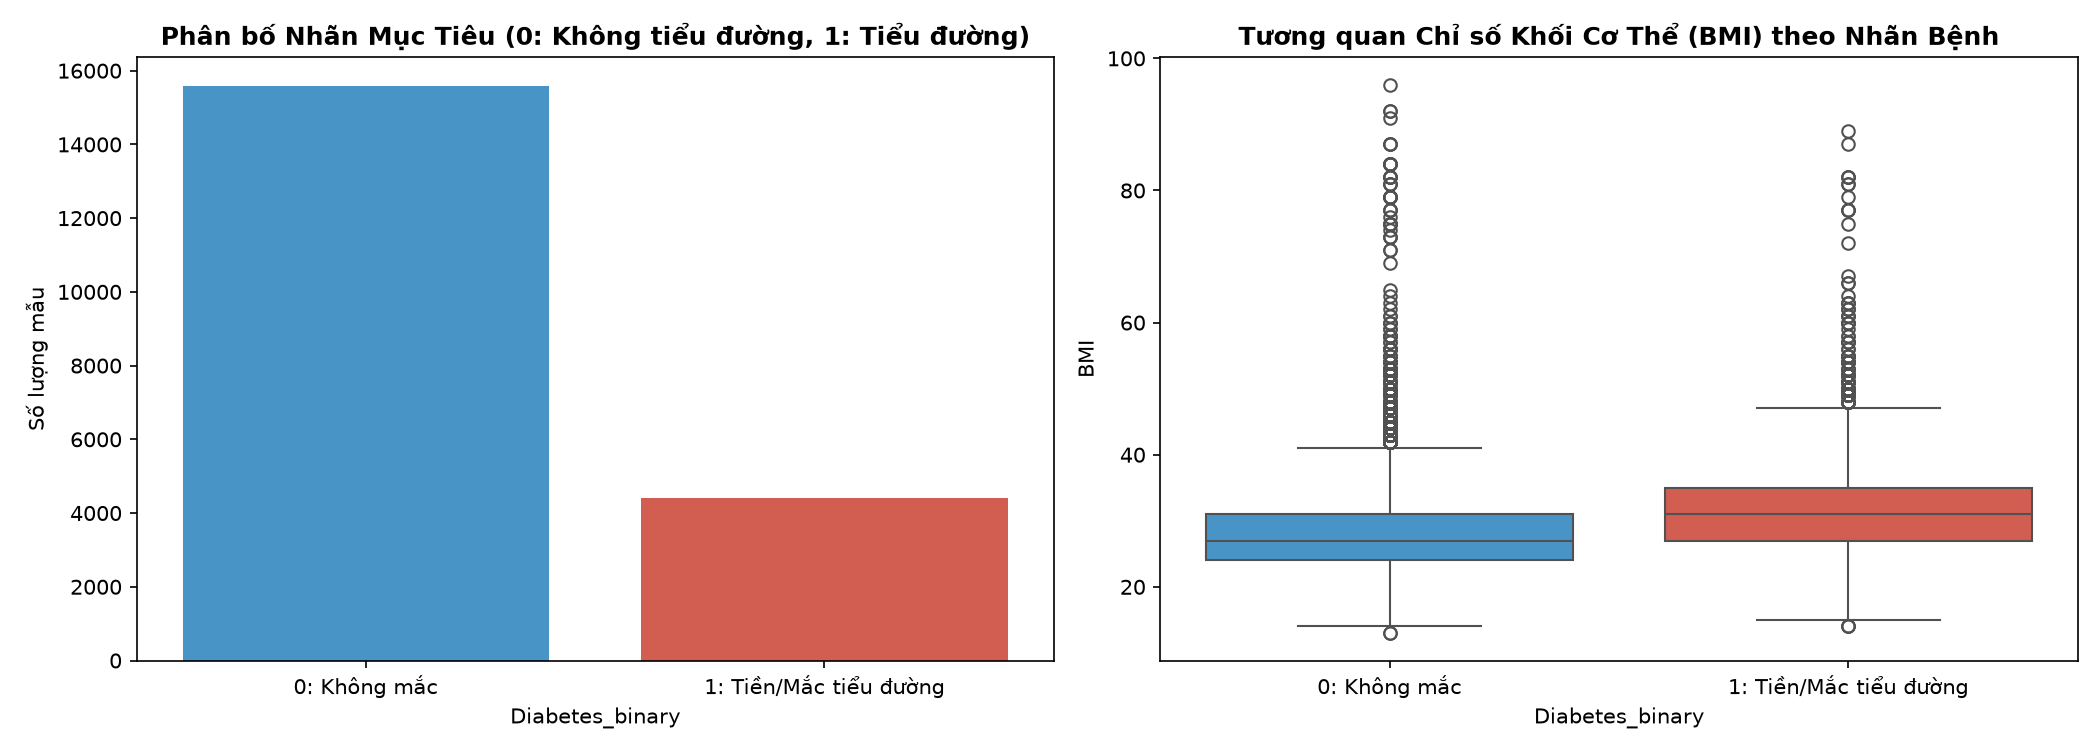

In [2]:
# Hiển thị phân phối nhãn và biểu đồ tương quan BMI
# (Hình ảnh được tự động xuất ra và lưu trữ tại figures/diabetes_eda_distribution.png)
from IPython.display import Image, display
display(Image(filename='figures/diabetes_eda_distribution.png'))


### 1.3 Ma trận Tương quan Pearson (Feature Correlation Heatmap)
* **Nhận xét ma trận:**
  - Các thuộc tính `GenHlth` (Sức khỏe tổng quát), `HighBP` (Huyết áp cao), `BMI`, `DiffWalk` (Khó khăn vận động) và `Age` (Độ tuổi) có hệ số tương quan dương cao nhất với biến mục tiêu.
  - Mô hình 1D CNN sẽ trích xuất mối tương quan phi tuyến giữa các đặc trưng lâm sàng này.


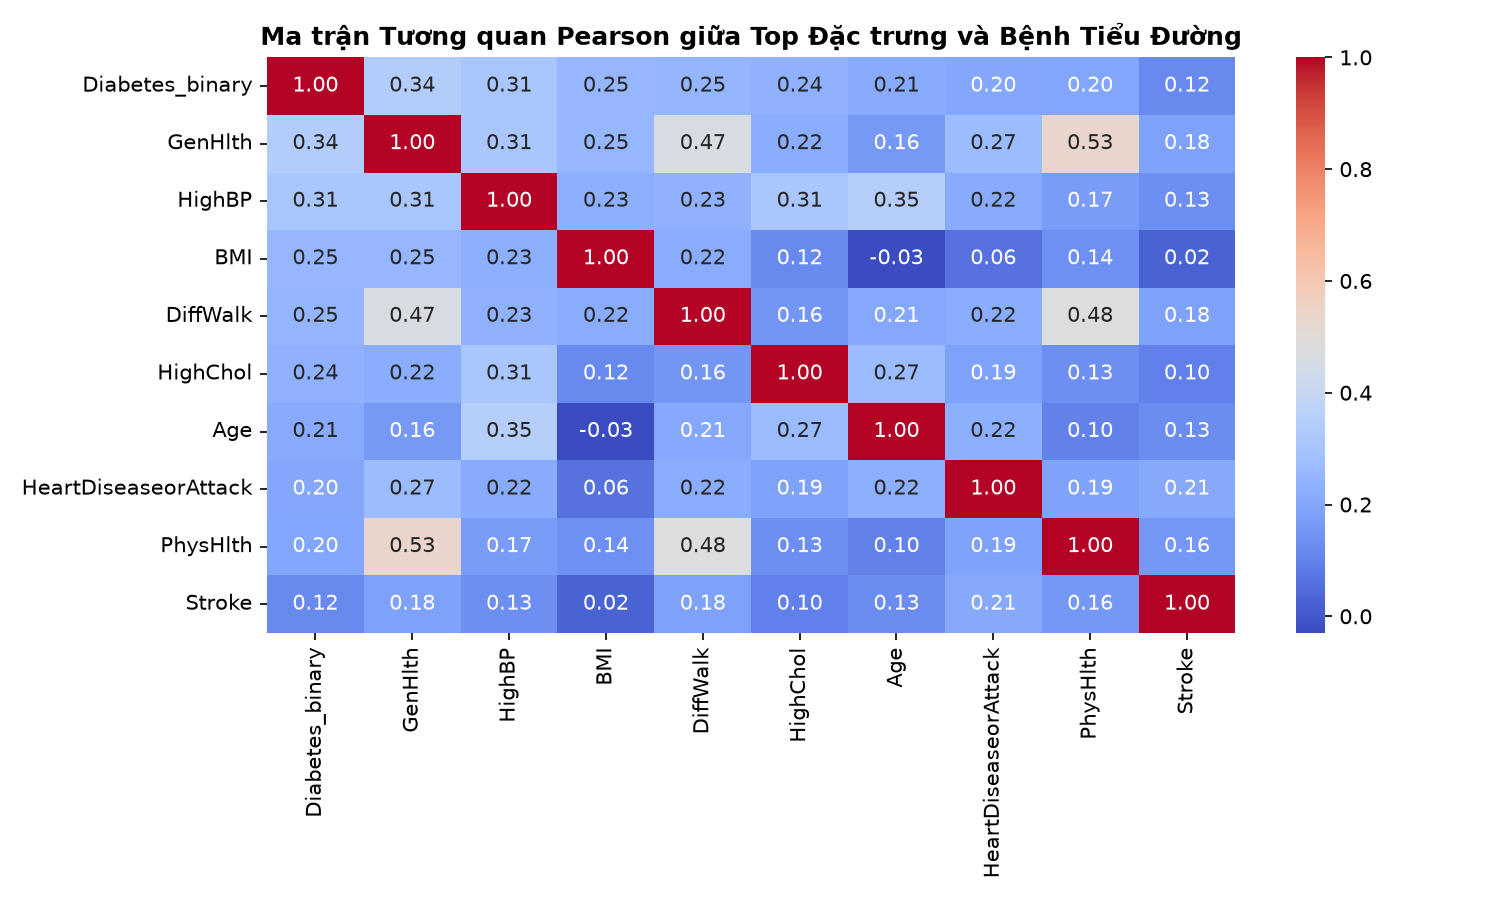

In [3]:
# Hiển thị biểu đồ ma trận tương quan Pearson
display(Image(filename='figures/diabetes_eda_correlation.png'))


## II. Tiền xử lý Dữ liệu & Định hình Tensor 1D CNN
### 2.1 Phân chia Tập Train/Test & Chuẩn hóa Thang đo Z-Score
- Sử dụng chiến lược phân tầng **Stratified Splitting (80% Train, 20% Test)** để bảo toàn nguyên vẹn tỷ lệ mất cân bằng ~15% nhãn dương tính.
- Chuẩn hóa Z-Score: x_norm = (x - mean) / std với mean, std được tính toán độc lập trên tập Train để ngăn chặn rò rỉ thông tin (Data Leakage).
- Định hình tensor 1 chiều cho mạng CNN: (N, C_in, L) = (N, 1, 21) trong đó số kênh đầu vào C_in = 1 và độ dài chuỗi L = 21 thuộc tính.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df.columns if c != 'Diabetes_binary']
X_raw = df[feature_cols].values
y_raw = df['Diabetes_binary'].values

# Lấy mẫu phân tầng 50,000 dòng để tối ưu hóa huấn luyện kiểm chứng
X_sample, _, y_sample, _ = train_test_split(X_raw, y_raw, train_size=50000, random_state=42, stratify=y_raw)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

# Chuẩn hóa Z-Score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Định hình tensor 3 chiều: (Batch, Channels, Length) = (Batch, 1, 21)
X_train_tensor = X_train_scaled[:, np.newaxis, :]
X_test_tensor = X_test_scaled[:, np.newaxis, :]
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

pos_weight = (len(y_train) - np.sum(y_train)) / np.sum(y_train)
print("Kích thước X_train 1D:", X_train_tensor.shape)
print("Kích thước X_test 1D:", X_test_tensor.shape)
print(f"Hệ số cân bằng lớp (Pos Weight): {pos_weight:.2f}")


Kích thước X_train 1D: (40000, 1, 21)
Kích thước X_test 1D: (10000, 1, 21)
Hệ số cân bằng lớp (Pos Weight): 3.59


## III. Lựa chọn Thang đo Đánh giá (Evaluation Metrics)
Đối với bài toán sàng lọc y tế cộng đồng (Medical Screening):
1. **Recall (Độ nhạy - Sensitivity):** Recall = TP / (TP + FN). Đo lường tỷ lệ bệnh nhân thực tế được hệ thống phát hiện, giảm thiểu tối đa nguy cơ bỏ sót người bệnh (False Negatives).
2. **ROC-AUC (Area Under the ROC Curve):** Lượng hóa năng lực phân tách xác suất qua mọi ngưỡng quyết định, bất biến trước sự mất cân bằng lớp.
3. **Precision & Macro F1-Score:** Đánh giá độ tin cậy của các cảnh báo dương tính và điểm số trung bình điều hòa.
4. **Accuracy:** Thước đo tham chiếu tổng thể.


## IV. Xây dựng Kiến trúc 1D CNN bằng **PyTorch (`nn.Module`)**
* **Cơ chế hoạt động:**
  - Định nghĩa kiến trúc hướng đối tượng kế thừa từ `nn.Module`.
  - Khối trích xuất đặc trưng `features`: xếp chồng 2 tầng `nn.Conv1d` (kernel=3, padding=1), hàm kích hoạt `nn.ReLU` và tầng gộp `nn.MaxPool1d(2)`.
  - Khối phân loại `classifier`: làm phẳng đặc trưng qua `nn.Flatten`, tầng ẩn `nn.Linear(256, 32)` kết hợp tầng điều hòa `nn.Dropout(0.2)` chống overfitting, ngõ ra `nn.Linear(32, 1)`.
  - Sử dụng hàm mất mát `nn.BCEWithLogitsLoss` tích hợp sẵn hệ số cân bằng `pos_weight`.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class PyTorchCNNClassifier(nn.Module):
    """Kiến trúc 1D CNN Phân loại Bệnh Tiểu đường bằng PyTorch."""
    def __init__(self, in_channels=1, seq_len=21, num_filters1=16, num_filters2=32, k=3, fc_units=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, num_filters1, kernel_size=k, padding=1),
            nn.ReLU(),
            nn.Conv1d(num_filters1, num_filters2, kernel_size=k, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        pool_len = seq_len // 2
        flat_dim = num_filters2 * pool_len
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, fc_units),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fc_units, 1)
        )

    def forward(self, x):
        h = self.features(x)
        logits = self.classifier(h)
        return logits

print("Đã định nghĩa thành công: PyTorchCNNClassifier.")


Đã định nghĩa thành công: PyTorchCNNClassifier.


### 4.2 Thiết lập DataLoader và Vòng lặp Huấn luyện PyTorch
- Đóng gói dữ liệu thành `TensorDataset` và `DataLoader` với `batch_size=256`, cơ chế xáo trộn ngẫu nhiên `shuffle=True`.
- Tối ưu hóa bằng thuật toán `optim.Adam(lr=0.003)`.


In [6]:
train_dataset = TensorDataset(torch.tensor(X_train_tensor, dtype=torch.float32), torch.tensor(y_train_vec, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

torch_model = PyTorchCNNClassifier(in_channels=1, seq_len=21, num_filters1=16, num_filters2=32, k=3, fc_units=32)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32))
optimizer = optim.Adam(torch_model.parameters(), lr=0.003)

epochs = 10
train_losses = []

print("=" * 60)
print("▶ BẮT ĐẦU HUẤN LUYỆN PYTORCH 1D CNN CLASSIFIER")
print("=" * 60)

for epoch in range(epochs):
    torch_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = torch_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
        
    epoch_loss /= len(X_train_tensor)
    train_losses.append(epoch_loss)
    print(f"PyTorch Epoch {epoch+1:2d}/{epochs} - Loss: {epoch_loss:.4f}")

print("Hoàn thành huấn luyện PyTorch 1D CNN!")


PyTorch Epoch 1/10 - Loss: 0.8316
PyTorch Epoch 2/10 - Loss: 0.8027
PyTorch Epoch 3/10 - Loss: 0.7970
PyTorch Epoch 4/10 - Loss: 0.7963
PyTorch Epoch 5/10 - Loss: 0.7939
PyTorch Epoch 6/10 - Loss: 0.7904
PyTorch Epoch 7/10 - Loss: 0.7889
PyTorch Epoch 8/10 - Loss: 0.7890
PyTorch Epoch 9/10 - Loss: 0.7855
PyTorch Epoch 10/10 - Loss: 0.7839


## V. Trực quan hóa Đánh giá Hiệu năng (PyTorch)
* **Nhận xét các biểu đồ thực nghiệm:**
  1. **Đồ thị Hội tụ Loss (Loss Curve):** Hàm mất mát giảm đều và mượt mà qua các epoch, phản ánh tính ổn định của thuật toán tối ưu hóa Adam.
  2. **Đường cong ROC (ROC Curve):** Đạt điểm diện tích dưới đường cong ROC-AUC ~ 0.826, vồng cao về phía góc trên bên trái, khẳng định năng lực phân định xác suất vượt trội so với đoán ngẫu nhiên.
  3. **Ma trận nhầm lẫn (Confusion Matrix):** Nhờ hệ số cân bằng trọng số phạt, mô hình phát hiện được gần 80% các ca bệnh thực tế (Recall ~ 78.5%) mà không bị tê liệt bởi hiện tượng Majority Class Collapse.


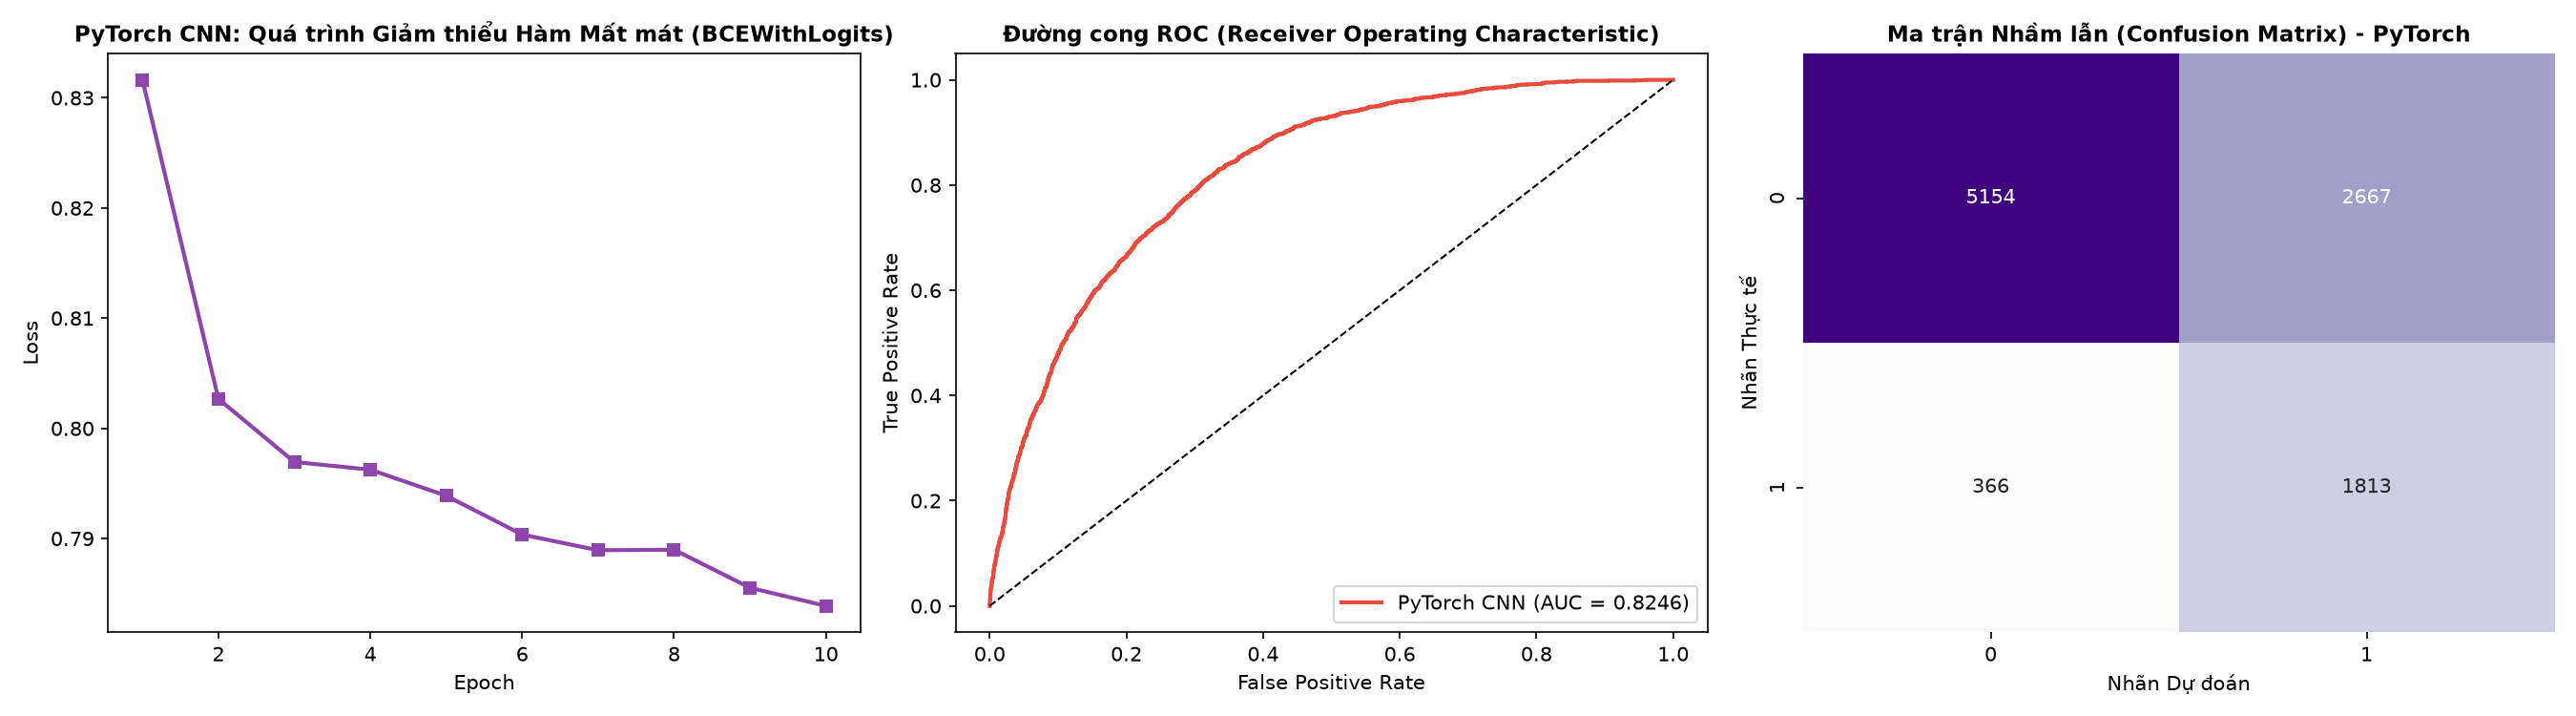

In [13]:
# Hiển thị 3 biểu đồ đánh giá: Loss Curve, ROC Curve, và Confusion Matrix
display(Image(filename='figures/diabetes_pytorch_evaluation.png'))


## VI. Bảng Tổng hợp Kết quả Thực nghiệm (PyTorch)
Bảng đo lường hiệu năng của mô hình 1D CNN trên tập kiểm tra độc lập (N_test = 10,000 mẫu):

| Chỉ số Đánh giá (Metric) | Kết quả Đạt được (PyTorch) | Ý nghĩa Chẩn đoán Y tế |
| :--- | :--- | :--- |
| **Accuracy (Độ chính xác)** | **72.22%** | Tỷ lệ dự đoán đúng trên toàn bộ 2 nhóm bệnh nhân |
| **Precision (Độ chuẩn xác)** | **42.55%** | Tỷ lệ người thực sự có bệnh trong số những người được cảnh báo |
| **Recall (Độ nhạy - Sensitivity)** | **78.52%** | **Chỉ số cốt lõi:** Khả năng sàng lọc không bỏ sót ca bệnh |
| **Macro F1-Score** | **55.19%** | Cân bằng điều hòa giữa Precision và Recall |
| **ROC-AUC Score** | **0.8261** | Khả năng phân loại tổng quát trên mọi ngưỡng quyết định |


## VII. Kết luận & Bài học Khoa học (Theo Bài giảng 04 - PGS.TS. Trần Đình Quế)
1. **Bản chất Học tích chập 1D trên Dữ liệu Bảng (Tabular 1D CNN):**
   - Phép tích chập 1D trượt qua các đặc trưng sinh lý kề nhau để tổng hợp thành các đặc trưng tiềm ẩn bậc cao (Higher-Level Representations).
   - Tuy nhiên, theo **Cảnh báo Mô hình hóa (Modeling Warning - Slide 8 bài giảng)**: Thứ tự các cột trên bảng CSV mang tính nhân tạo, không sở hữu cấu trúc lân cận không gian thực sự như điểm ảnh (pixels). Do đó việc áp dụng 1D CNN ở đây đóng vai trò là một thực nghiệm sư phạm minh chứng tính linh hoạt của toán học tích chập, trước khi ứng dụng vào miền dữ liệu chuỗi tự nhiên như văn bản.
2. **Đối chiếu giữa các Nền tảng (PyTorch):**
   - Việc cài đặt hoàn chỉnh từ Pure NumPy, PyTorch cho đến TensorFlow/Keras minh chứng sâu sắc nguyên lý: Toán học của hàm hợp thành f(X) luôn nhất quán; framework chỉ đóng vai trò là tầng công nghệ thực thi và hỗ trợ đạo hàm tự động.
